# 实验对比记录

本 Notebook 记录不同 Trainer 在 Dataset003_Liver 上的测试结果对比，便于追踪改进效果。

---

## 实验一：Baseline vs SizeOversampleV2

**日期**：2026-05-29  
**数据集**：Dataset003_Liver，测试集 26 cases  
**对比对象**：
- `nnUNetTrainer_Baseline__nnUNetPlans__3d_fullres / fold_0`
- `nnUNetTrainer_SizeOversampleV2__nnUNetPlans__3d_fullres / fold_0`

**SizeOversampleV2 改动思路**：对极小/小肿瘤和无肿瘤 case 加大过采样倍数，期望提升小肿瘤召回和降低误报。

### 1. 核心指标

| 指标 | Baseline | SizeOversampleV2 | 变化 |
|------|----------|------------------|------|
| Liver Dice | 0.9340 | **0.9516** | +0.0176 ✅ |
| Tumor Dice | 0.6542 | **0.6858** | +0.0316 ✅ |
| Overall（两类均值） | 0.7941 | **0.8187** | +0.0246 ✅ |
| Recall（有肿瘤 n=23） | **0.7853** | 0.7105 | −0.0748 ❌ |
| Precision | 0.6451 | **0.7490** | +0.1039 ✅ |
| FDR | 0.3549 | **0.2110** | −0.1439 ✅ |
| 无肿瘤误报率 | 100%（3/3） | **66.67%（2/3）** | liver_89 修复 ✅ |

### 2. FPV / FNV 体积误差（mm³）

| | Baseline | SizeOversampleV2 | 变化 |
|--|----------|------------------|------|
| Tumor FPV 总量 | 419,617 | **278,777** | −33% ✅ |
| Tumor FNV 总量 | **540,349** | 648,421 | +20% ❌ |
| Liver FPV 总量 | 5,656,937 | **3,396,663** | −40% ✅ |
| Liver FNV 总量 | **946,282** | 1,349,741 | +43% ❌ |

> FPV 减少说明假阳性体积大幅下降，但 FNV 增加说明漏检更多（召回率下降的体积体现）。

### 3. 病灶级检出率（lesion-wise detection rate）

| 最小体素阈值 | Baseline | SizeOversampleV2 | 变化 |
|------------|----------|------------------|------|
| ≥ 0 体素 | 84.6%（230/272） | 77.9%（212/272） | −6.7% ❌ |
| ≥ 10 体素 | 93.8%（227/242） | 86.8%（210/242） | −7.0% ❌ |
| ≥ 100 体素（临床有意义） | **95.7%**（220/230） | 88.3%（203/230） | −7.4% ❌ |
| ≥ 500 体素 | **98.2%**（161/164） | 95.1%（156/164） | −3.1% ❌ |

> 临床有意义阈值（≥100 体素）检出率下降 7.4%，说明 SizeOversampleV2 对小肿瘤敏感性明显变差。

### 4. 按肿瘤大小分组的 Dice

| 大小分类 | Baseline Dice | SizeOversampleV2 Dice | 变化 |
|---------|--------------|----------------------|------|
| 极小（<5k 体素） | 0.5386 | **0.5582** | +0.020 ✅ |
| 小（5k–50k） | **0.7928** | 0.7999 | +0.007 ≈ |
| 中等（50k–300k） | **0.7486** | 0.7165 | −0.032 ❌ |
| 大（≥300k） | 0.8359 | **0.8351** | ≈ |

### 5. 结论与分析

**SizeOversampleV2 是一次典型的 Precision ↑ / Recall ↓ 权衡。**

**收益：**
- Liver Dice +0.018，分割轮廓更精准
- Tumor Overall +0.025
- 假阳性体积大幅减少（Tumor FPV −33%，Liver FPV −40%）
- 无肿瘤误报从 3/3 降到 2/3（liver_89 修复）

**代价：**
- Recall −0.075，漏检显著增加
- 临床有意义的病灶级检出率 −7.4%（88.3% vs 95.7%）
- FNV 增加 20%，中等肿瘤 Dice 下降

**根本原因推断：**  
无肿瘤×6 过采样使模型过于保守，宁可漏检也不误报，导致召回率下降。

**后续方向：**
- [x] SizeOversampleV3：极小×8 / 小×6 / 中×3 / 极大×3 / 无肿瘤×6，全尺寸均衡过采样（进行中）
- [ ] 分析具体失败 case（见下方可视化）

---

## 困难 Case 可视化

对 Baseline 和 V2 中表现最差的 case 进行切片可视化，直观分析失败原因。

**颜色约定**：
- 🟡 黄色：GT 肿瘤（真实标注）
- 🔴 红色：FP（预测出肿瘤但 GT 无，假阳性）
- 🔵 蓝色：FN（GT 有肿瘤但预测漏掉，假阴性）
- 🟢 绿色：TP（预测正确的肿瘤区域）

In [ ]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ── 路径配置 ──────────────────────────────────────────────
RAW_DIR  = Path('/home/PuMengYu/nnUNet_workspace/raw/Dataset003_Liver/imagesTr')
GT_DIR   = Path('/home/PuMengYu/nnUNet_workspace/preprocessed/Dataset003_Liver/gt_segmentations')
PRED_DIR = {
    'Baseline': Path('/home/PuMengYu/nnUNet_workspace/results_v2/Dataset003_Liver/nnUNetTrainer_Baseline__nnUNetPlans__3d_fullres/fold_0/test_prediction'),
    'V2':       Path('/home/PuMengYu/nnUNet_workspace/results_v2/Dataset003_Liver/nnUNetTrainer_SizeOversampleV2__nnUNetPlans__3d_fullres/fold_0/test_prediction'),
}

def load_nii(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(str(path)))  # shape: (Z, Y, X)

def find_best_slice(gt, pred=None):
    """找肿瘤 GT 体素最多的轴向切片"""
    tumor_mask = (gt == 2)
    if pred is not None:
        tumor_mask = tumor_mask | (pred == 2)
    counts = tumor_mask.sum(axis=(1, 2))
    return int(counts.argmax())

def visualize_case(case_name, trainers=('Baseline', 'V2'), window=(-100, 200)):
    ct  = load_nii(RAW_DIR  / f'{case_name}_0000.nii.gz')
    gt  = load_nii(GT_DIR   / f'{case_name}.nii.gz')

    preds = {}
    for t in trainers:
        p = PRED_DIR[t] / f'{case_name}.nii.gz'
        if p.exists():
            preds[t] = load_nii(p)

    n_cols = 1 + len(preds)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
    fig.suptitle(f'{case_name}  |  GT 肿瘤体素: {(gt==2).sum():,}', fontsize=14)

    ct_clipped = np.clip(ct, window[0], window[1])
    z = find_best_slice(gt, list(preds.values())[0] if preds else None)

    def make_overlay(gt_slice, pred_slice):
        overlay = np.zeros((*gt_slice.shape, 4))
        tp = (gt_slice == 2) & (pred_slice == 2)
        fp = (gt_slice != 2) & (pred_slice == 2)
        fn = (gt_slice == 2) & (pred_slice != 2)
        overlay[tp] = [0.0, 0.9, 0.0, 0.5]  # 绿: TP
        overlay[fp] = [1.0, 0.0, 0.0, 0.6]  # 红: FP
        overlay[fn] = [0.0, 0.4, 1.0, 0.6]  # 蓝: FN
        return overlay

    # 第 0 列：GT
    ax = axes[0] if n_cols > 1 else axes
    ax.imshow(ct_clipped[z], cmap='gray', interpolation='nearest')
    gt_overlay = np.zeros((*gt[z].shape, 4))
    gt_overlay[gt[z] == 2] = [1.0, 1.0, 0.0, 0.5]
    gt_overlay[gt[z] == 1] = [1.0, 0.5, 0.0, 0.15]
    ax.imshow(gt_overlay, interpolation='nearest')
    ax.set_title(f'GT  (slice z={z})')
    ax.axis('off')

    legend = [
        mpatches.Patch(color='green', alpha=0.6, label='TP'),
        mpatches.Patch(color='red',   alpha=0.7, label='FP'),
        mpatches.Patch(color='blue',  alpha=0.7, label='FN'),
    ]
    for i, (name, pred) in enumerate(preds.items()):
        ax = axes[i + 1]
        ax.imshow(ct_clipped[z], cmap='gray', interpolation='nearest')
        ax.imshow(make_overlay(gt[z], pred[z]), interpolation='nearest')
        tp = int(((gt==2) & (pred==2)).sum())
        fp = int(((gt!=2) & (pred==2)).sum())
        fn = int(((gt==2) & (pred!=2)).sum())
        dice = 2*tp / (2*tp + fp + fn + 1e-6)
        ax.set_title(f'{name}  Dice={dice:.3f}\nTP={tp:,}  FP={fp:,}  FN={fn:,}')
        ax.legend(handles=legend, loc='lower right', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print('工具函数加载完毕')

### 严重失败 case

/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-7624}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/PuMengYu/anaconda3/envs/medseg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/PuMengYu/anaconda3/envs/medseg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-762

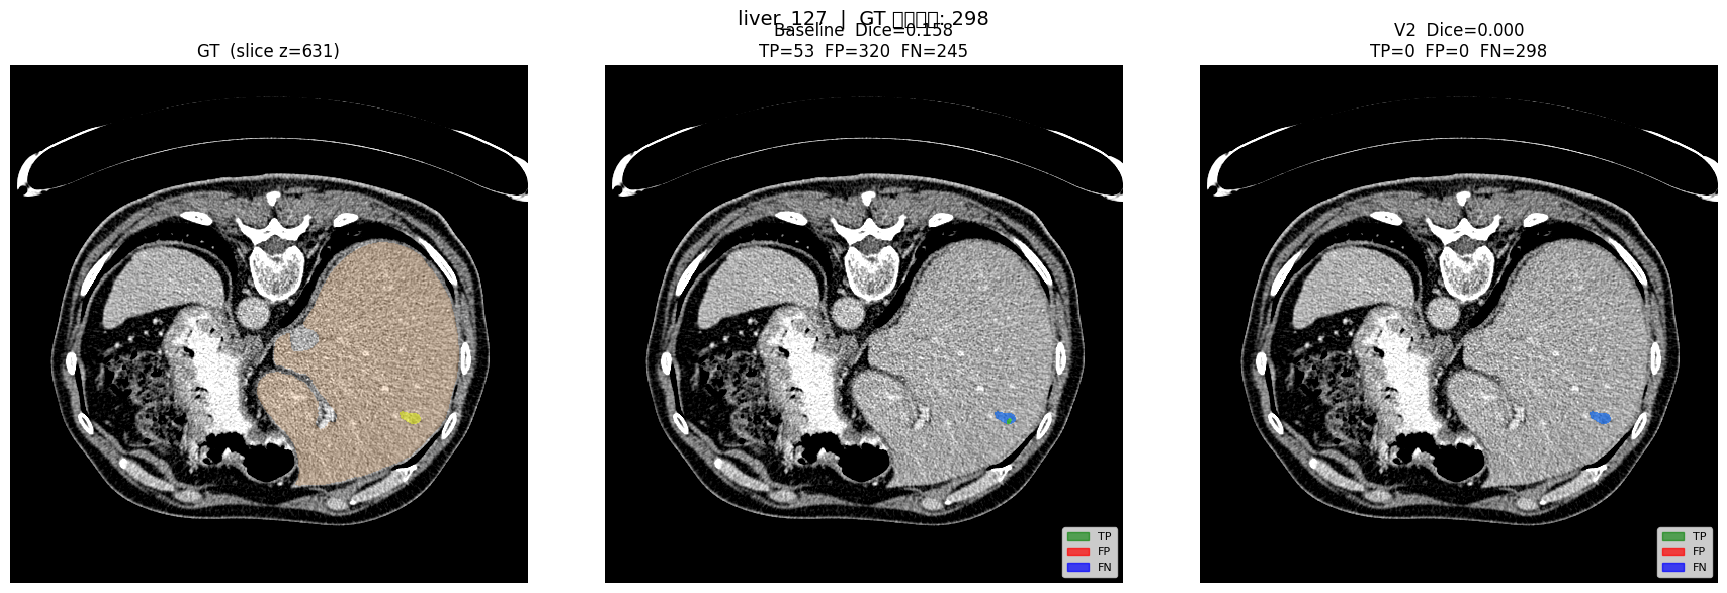

In [4]:
# liver_127：极小肿瘤（298体素），Baseline Dice=0.158，V2 完全漏掉(Dice=0)
visualize_case('liver_127')

/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-7624}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


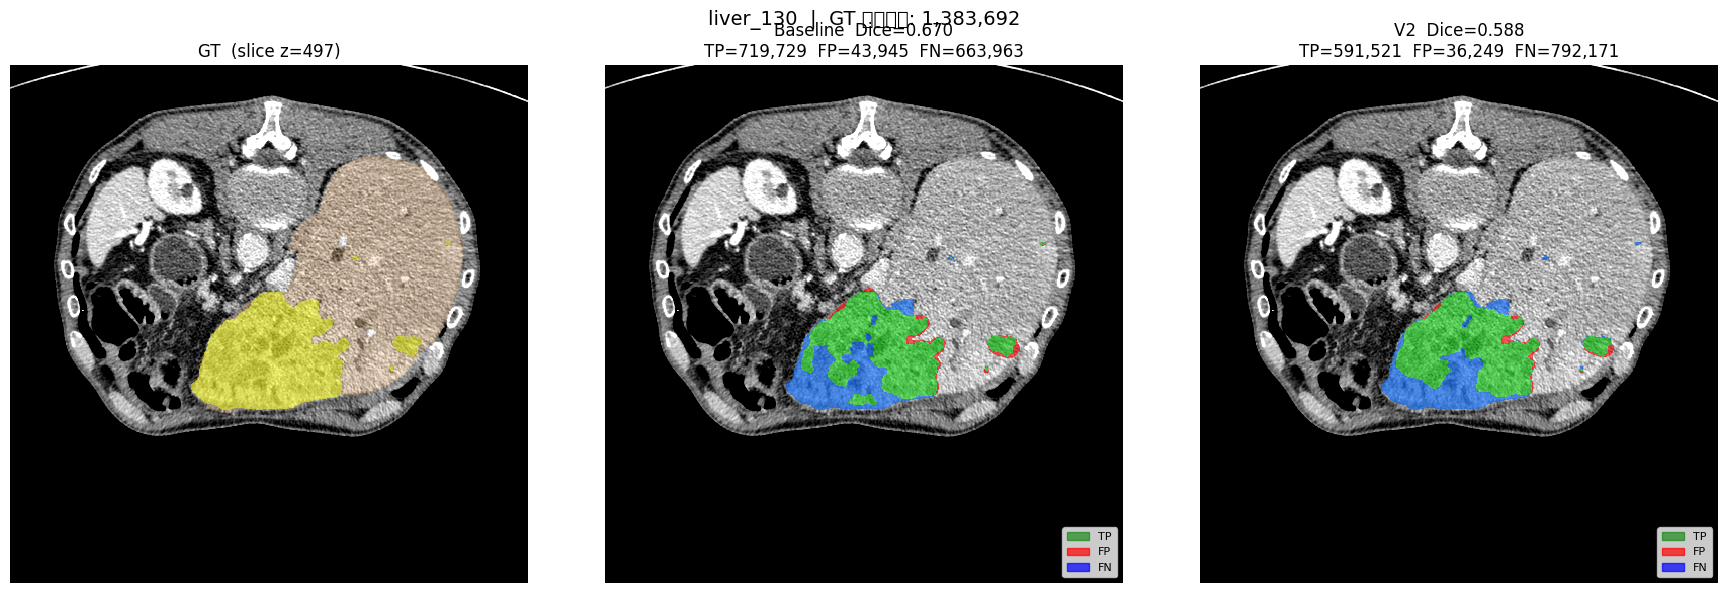

In [5]:
# liver_130：大肿瘤但 FNV 极高（217,189 mm³），两个模型 recall 都很低
visualize_case('liver_130')

/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-7624}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


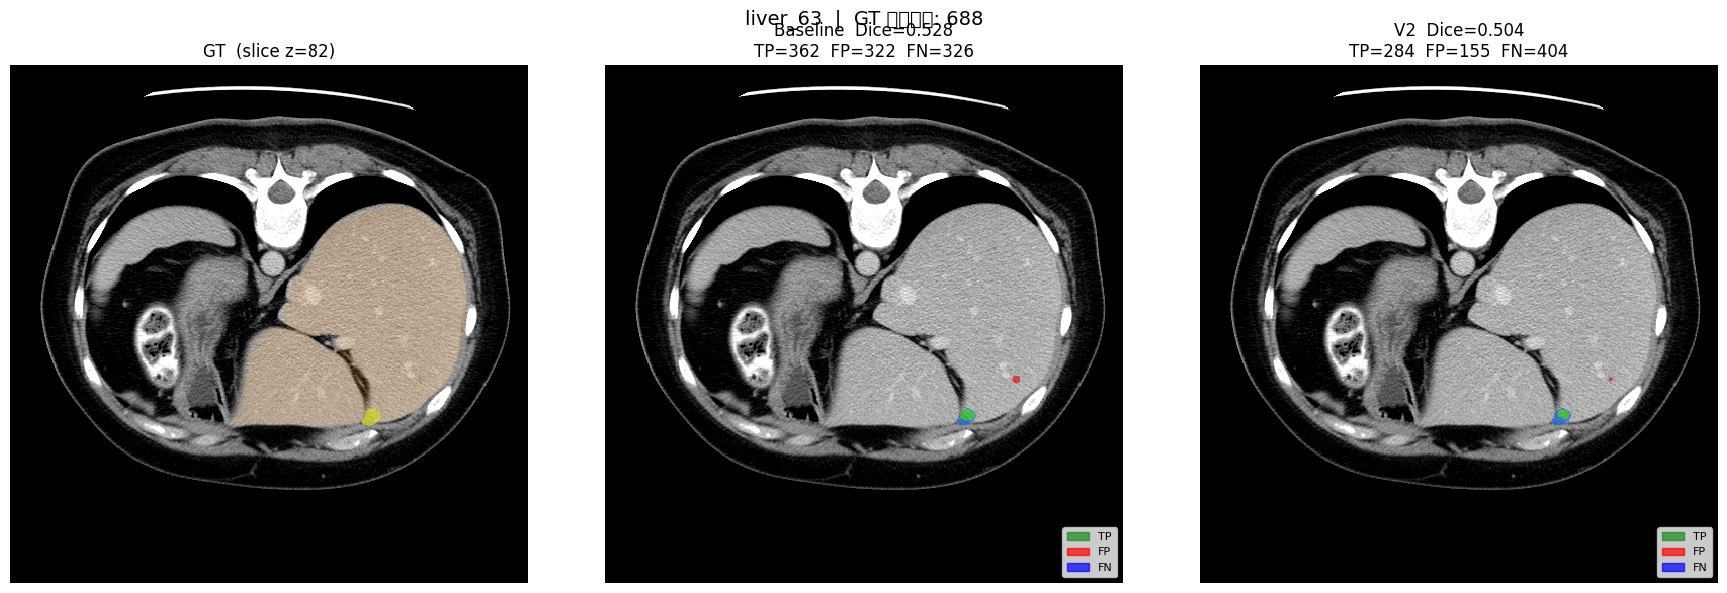

In [6]:
# liver_63：极小肿瘤（688体素），两个模型都在「需要改进」区间
visualize_case('liver_63')

### 无肿瘤误报 case（FP case）

/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-7624}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


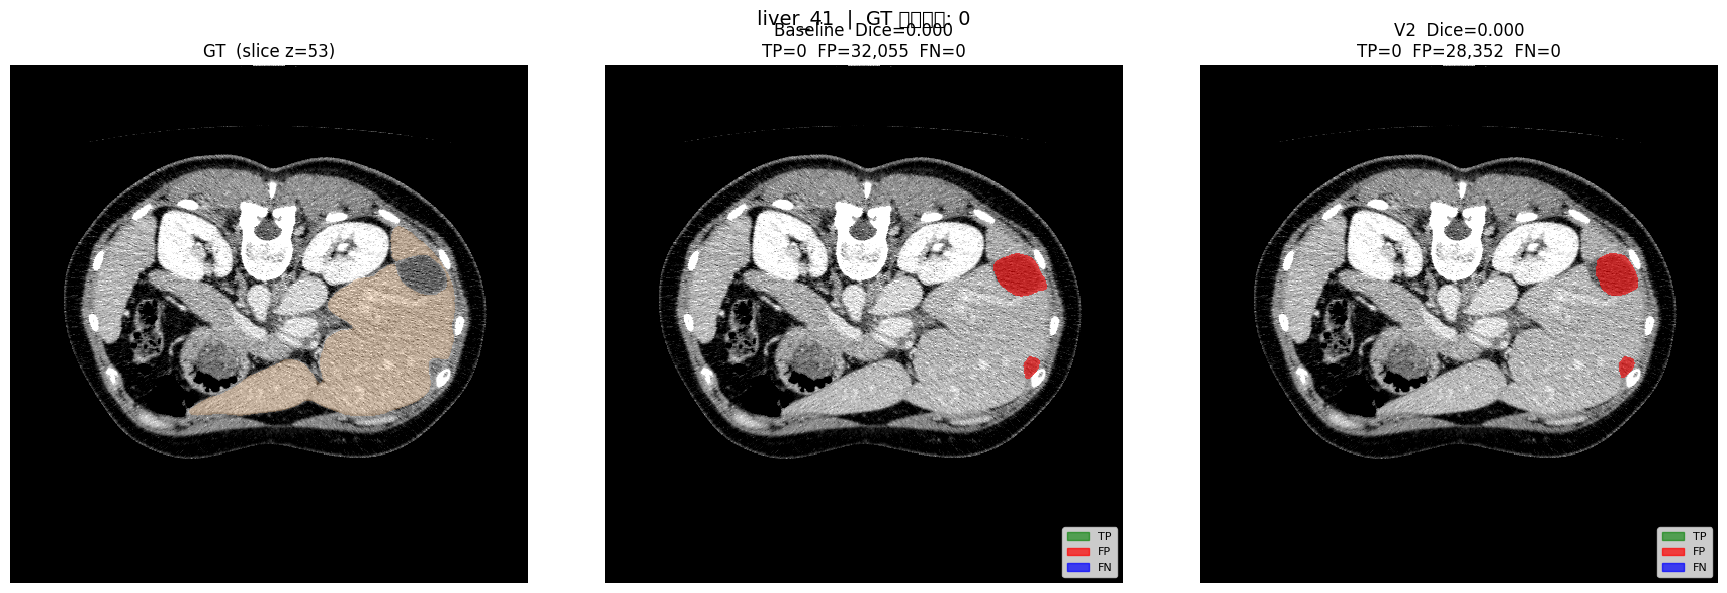

In [8]:
# liver_41：GT 无肿瘤，Baseline 误报 32,055 体素，V2 误报 28,352 体素
visualize_case('liver_41')

/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-7624}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


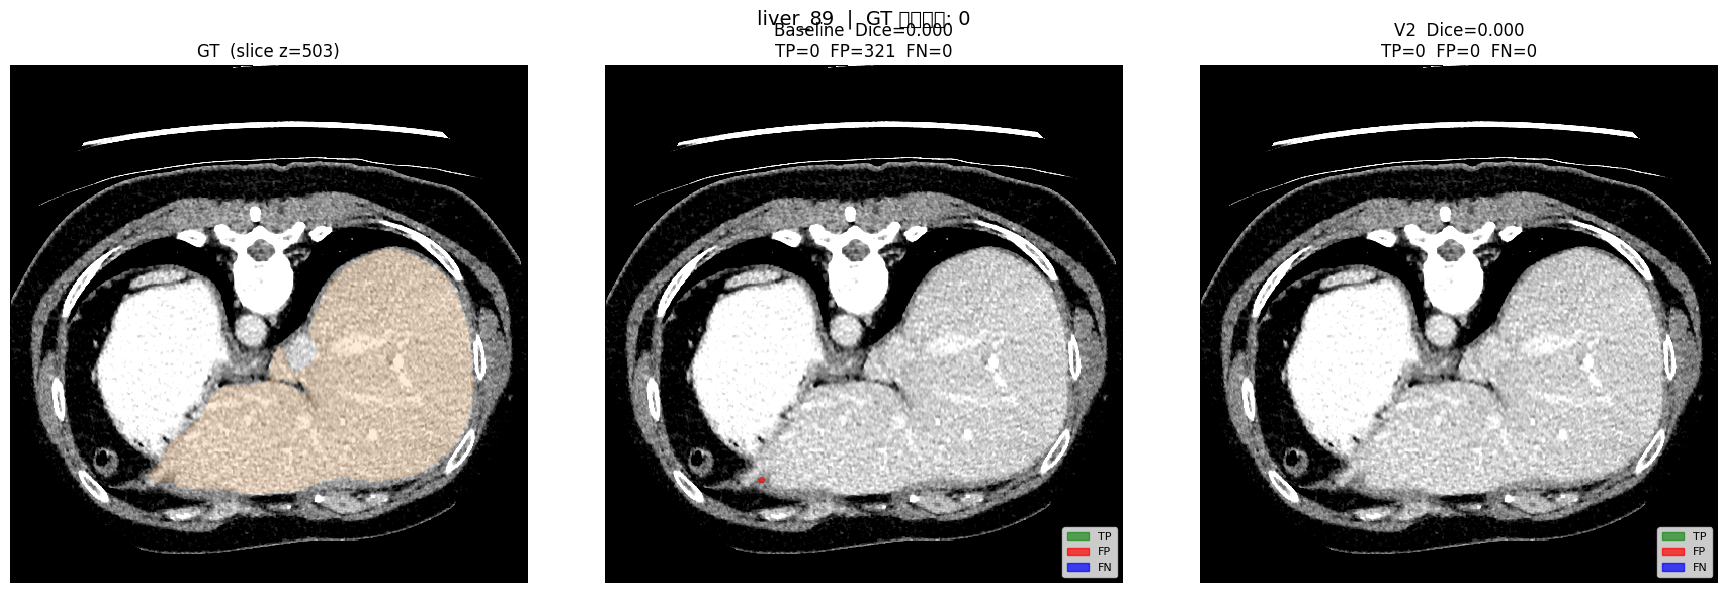

In [7]:
# liver_89：GT 无肿瘤，Baseline 误报 321 体素，V2 修复（pred=0）
# 观察 V2 为什么能修复这个 case
visualize_case('liver_89')

### 自定义查看任意 case

修改 `case_name` 查看任意 case，`window` 参数调整 CT 窗宽窗位（腹部软组织一般用 -100~200）。

/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-7624}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3615326/1519198196.py:83: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


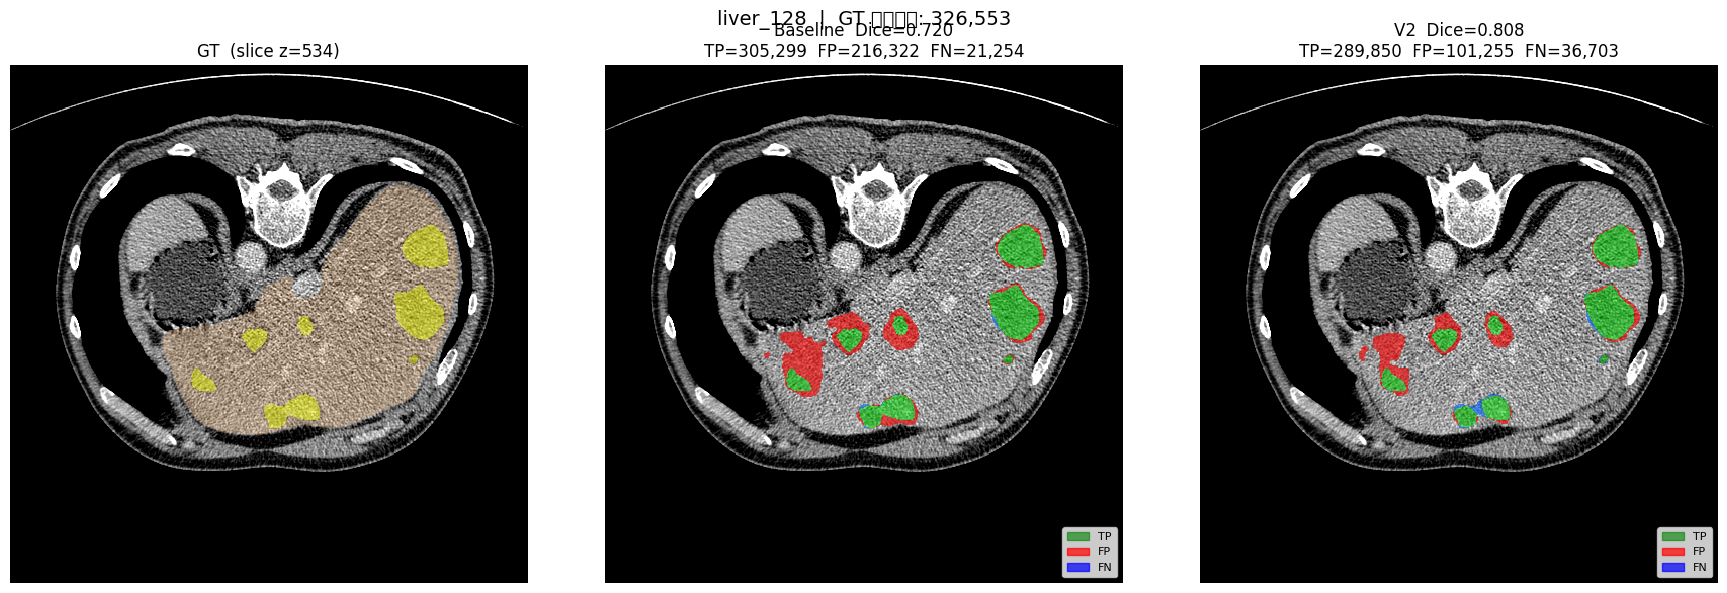

In [9]:
visualize_case('liver_128', window=(-100, 200))

---

## 实验模板（复制此节添加新实验）

### 实验 N：A vs B

**日期**：  
**改动说明**：  

| 指标 | A | B | 变化 |
|------|---|---|------|
| Liver Dice | | | |
| Tumor Dice | | | |
| Overall | | | |
| Recall | | | |
| Precision | | | |
| 病灶检出率 ≥100体素 | | | |

**结论**：

**后续方向**：
- [ ] ...